In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data = pd.read_csv("/content/golden_mine.csv")
data.head()

,Payments,Costs,Profit,Age,Gender,AgeGroup
0,9400,8100,1300,19,male,18-24
1,26600,13900,12700,29,male,25-39
2,9750,6750,3000,20,male,18-24
3,29700,11200,18500,18,female,18-24
4,49700,10450,39250,21,female,18-24


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8715 entries, 0 to 8714
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Payments  8715 non-null   int64 
 1   Costs     8715 non-null   int64 
 2   Profit    8715 non-null   int64 
 3   Age       8715 non-null   int64 
 4   Gender    8715 non-null   object
 5   AgeGroup  8715 non-null   object
dtypes: int64(4), object(2)
memory usage: 408.6+ KB


In [ ]:
data.describe()

,Payments,Costs,Profit,Age
count,8.715000e+03,8.715000e+03,8.715000e+03,8715.000000
mean,3.009787e+04,1.469063e+04,1.540725e+04,22.393001
std,7.605124e+04,1.036618e+05,1.271005e+05,5.877830
min,3.750000e+03,3.500000e+03,-9.643950e+06,18.000000
25%,1.080000e+04,8.350000e+03,2.500000e+03,18.000000
50%,1.985000e+04,1.145000e+04,7.850000e+03,19.000000
75%,4.005000e+04,1.535000e+04,2.375000e+04,25.000000
max,6.654600e+06,9.661700e+06,6.643950e+06,49.000000


<Axes: ylabel='Payments'>

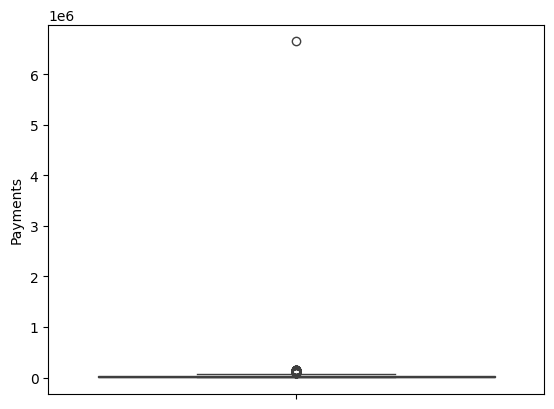

In [ ]:
#далее рассмотрим графики и выбросы
sns.boxplot(data["Payments"])

<Axes: ylabel='Costs'>

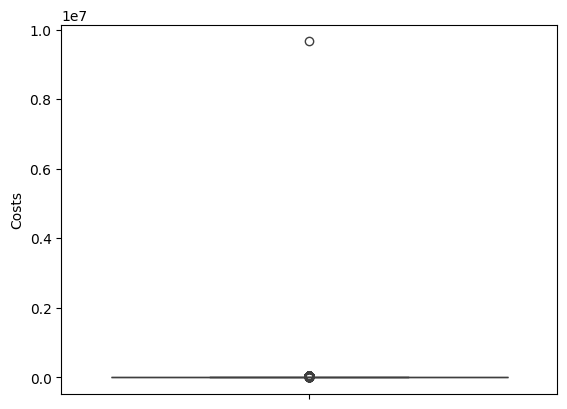

In [ ]:
sns.boxplot(data["Costs"])

<Axes: ylabel='Profit'>

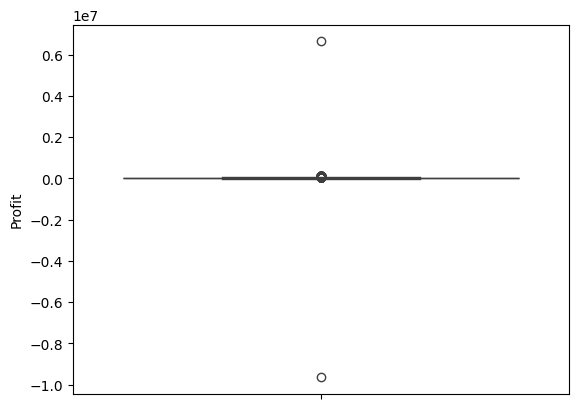

In [ ]:
sns.boxplot(data["Profit"])

In [ ]:
data = data[(data["Payments"] < 1000000) & (data["Costs"] < 8000000)]
data['Gender'] = data["Gender"].str.lower()

<Axes: ylabel='Payments'>

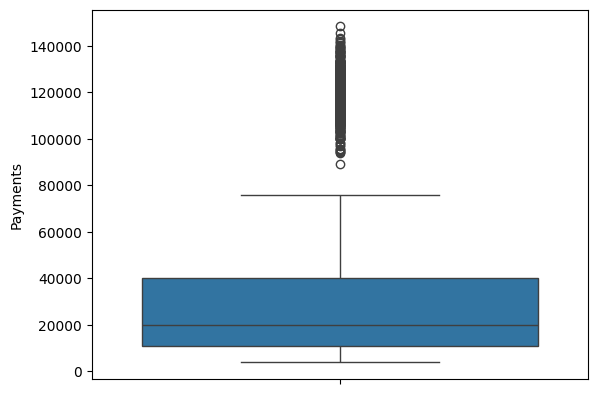

In [ ]:
sns.boxplot(data["Payments"])

<Axes: ylabel='Costs'>

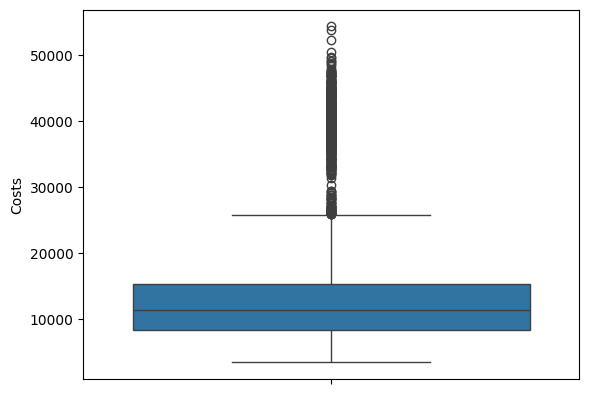

In [ ]:
sns.boxplot(data["Costs"])

In [ ]:
#кол-во клиентов
len(data)

8713

In [ ]:
#прибыль от каждого клиента
data["Profit"].median()

7850.0

In [ ]:
# Клиентов планируется привести: 1000
# Цена привлечения одного клиента: 15000
# Профит от медианного клиента небольшой в сравнении с ценой привлечения

<Axes: ylabel='Profit'>

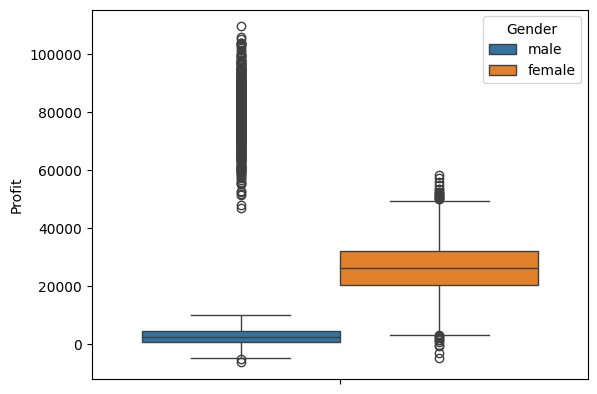

In [ ]:
#Медианное значение профита с женщин 18-24 года:
sns.boxplot(data[(data["AgeGroup"] == "18-24")], y="Profit", hue="Gender")

<Axes: xlabel='AgeGroup', ylabel='Gender'>

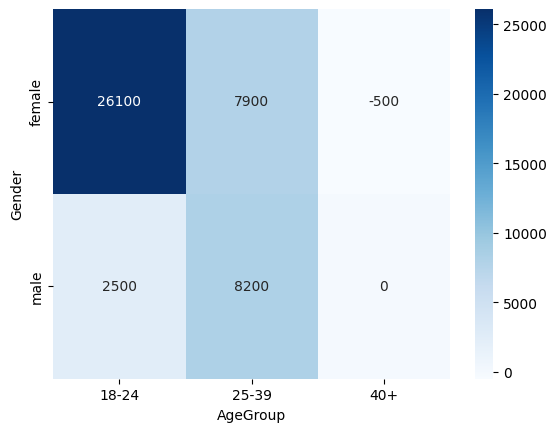

In [ ]:
#Таблица медианных значений по годам и полам:
sns.heatmap(data.pivot_table(index="Gender", columns="AgeGroup", aggfunc="median", values="Profit"), cmap="Blues", annot=True, fmt='.0f')

In [ ]:
#поменяем возрастные группы:
groups = [(18, 20), (21, 22), (23, 24), (25, 26), (27, 28), (29, 30), (31, 32), (33, 34), (35, 100)]
print(data["Age"].dtype)
for gr in groups:
    data.loc[(gr[0] <= data["Age"]) & (data["Age"] <= gr[1]), "AgeGroup"] = str(gr[0]) + "-" + str(gr[1])
data

int64


,Payments,Costs,Profit,Age,Gender,AgeGroup
0,9400,8100,1300,19,male,18-20
1,26600,13900,12700,29,male,29-30
2,9750,6750,3000,20,male,18-20
3,29700,11200,18500,18,female,18-20
4,49700,10450,39250,21,female,21-22
...,...,...,...,...,...,...
8710,8650,8600,50,18,male,18-20
8711,45350,14350,31000,19,female,18-20
8712,41700,9900,31800,18,female,18-20
8713,120600,49650,70950,21,male,21-22


<Axes: xlabel='AgeGroup', ylabel='Gender'>

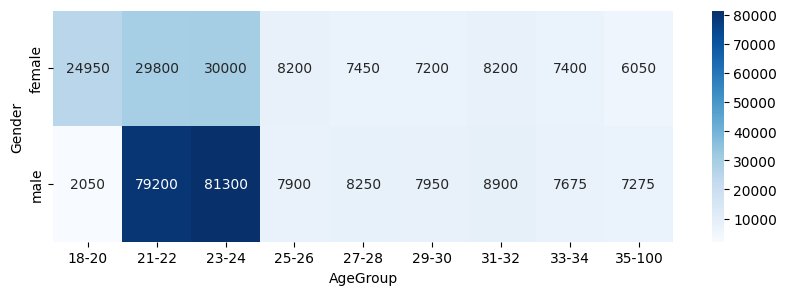

In [ ]:
#распределение после изменения групп:
plt.figure(figsize=(10, 3))
sns.heatmap(data.pivot_table(index="Gender", columns="AgeGroup", aggfunc="median", values="Profit"), cmap="Blues", annot=True, fmt='.0f')

<Axes: xlabel='Gender', ylabel='Age'>

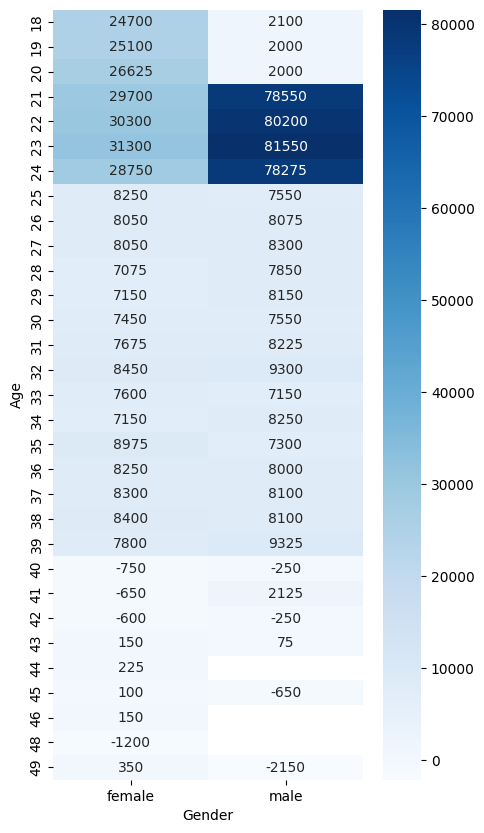

In [ ]:
#Попробуем построить распределение не по группам, а по возрасту
plt.figure(figsize=(5, 10))
sns.heatmap(data.pivot_table(index="Age", columns="Gender", aggfunc="median", values="Profit"), cmap="Blues", annot=True, fmt='.0f')